# 03 — Offline Bandit Evaluation

Compares the three bandit policies (Thompson Sampling, UCB1, Baseline) against the golden evaluation set using the **Replay Method** — an unbiased offline estimator.

**Replay Method:** Reward is assigned only when the policy selects the same arm that was shown historically. This prevents selection bias in offline evaluation.

> Reference: Li et al., 2010 — *A Contextual-Bandit Approach to Personalized News Article Recommendation*

In [1]:
from pathlib import Path
import sys

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 4)

print(f"Working from: {ROOT}")

Working from: /Volumes/zeus/project/project_persona/git-portfolio/postech-fiap-ml-tech-challege-5-datathon


## 1. Load Golden Set

In [2]:
golden_path = ROOT / "datasets" / "golden_set" / "evaluation_cases.parquet"

if not golden_path.exists():
    print("Golden set not found — generating synthetic data first...")
    from src.data.loader import clean, save_processed, PROCESSED_PATH
    from src.data.synthetic import save_all
    if not PROCESSED_PATH.exists():
        save_processed(clean())
    save_all()

golden = pd.read_parquet(golden_path)
print(f"Golden set: {len(golden)} records")
print(f"Arms: {golden['arm_historical'].unique().tolist()}")
golden.head(3)

Golden set: 500 records
Arms: ['term_deposit_6m', 'personal_loan', 'term_deposit_12m']


,case_id,arm_historical,reward,client_segment,age,job,education,housing,euribor3m
0,case_0000,term_deposit_6m,0,age_young,32,technician,university.degree,no,4.966
1,case_0001,personal_loan,1,indebted,48,admin.,basic.9y,yes,4.859
2,case_0002,personal_loan,1,indebted,41,blue-collar,basic.4y,no,1.410


## 2. Run Comparison

In [3]:
from src.evaluation.offline import run_comparison

results = run_comparison()
print("Evaluation complete.")

summary_rows = []
for policy_name, result in results.items():
    summary_rows.append({
        "policy": policy_name,
        "cumulative_reward": result.cumulative_reward,
        "avg_reward": result.avg_reward,
        "regret": result.regret,
        "exploration_rate": result.exploration_rate,
        "total_cases": result.total_cases,
    })

summary = pd.DataFrame(summary_rows).set_index("policy").sort_values("cumulative_reward", ascending=False)
print(summary.round(4))

[baseline  ] cumulative_reward=12.0 avg=0.0240 regret=91.0 exploration=0.00%
[thompsonsampling] cumulative_reward=36.0 avg=0.0720 regret=67.0 exploration=67.20%
[ucb1      ] cumulative_reward=27.0 avg=0.0540 regret=76.0 exploration=49.80%
Evaluation complete.
                  cumulative_reward  avg_reward  regret  exploration_rate  \
policy                                                                      
thompsonsampling               36.0       0.072    67.0             0.672   
ucb1                           27.0       0.054    76.0             0.498   
baseline                       12.0       0.024    91.0             0.000   

                  total_cases  
policy                         
thompsonsampling          500  
ucb1                      500  
baseline                  500  


## 3. Cumulative Reward Curve

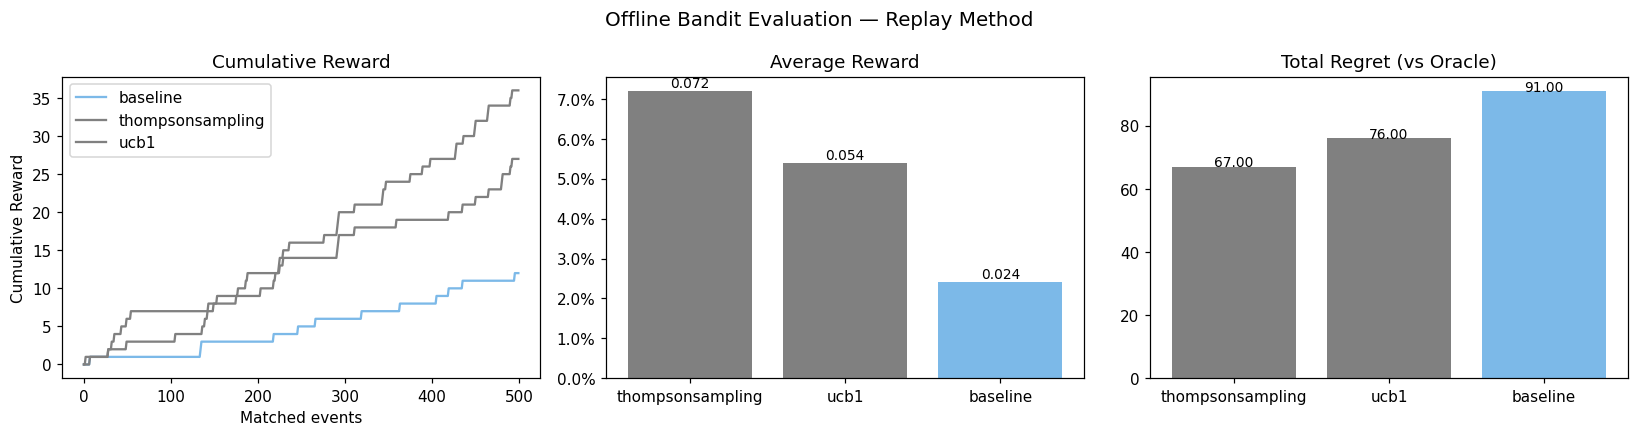

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {"thompson": "#E84040", "ucb": "#4A90D9", "baseline": "#7CB9E8"}

for policy_name, result in results.items():
    rewards = result.rewards
    if not rewards:
        continue
    color = colors.get(policy_name, "gray")
    cumsum = np.cumsum(rewards)
    axes[0].plot(cumsum, label=policy_name, color=color)

axes[0].set_title("Cumulative Reward")
axes[0].set_xlabel("Matched events")
axes[0].set_ylabel("Cumulative Reward")
axes[0].legend()

# Average reward bars
policies = list(summary.index)
avg_rewards = [summary.loc[p, "avg_reward"] for p in policies]
bar_colors = [colors.get(p, "gray") for p in policies]

axes[1].bar(policies, avg_rewards, color=bar_colors)
axes[1].set_title("Average Reward")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i, v in enumerate(avg_rewards):
    axes[1].text(i, v + 0.001, f"{v:.3f}", ha="center", fontsize=9)

# Regret bars
regrets = [summary.loc[p, "regret"] for p in policies]
axes[2].bar(policies, regrets, color=bar_colors)
axes[2].set_title("Total Regret (vs Oracle)")
for i, v in enumerate(regrets):
    axes[2].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle("Offline Bandit Evaluation — Replay Method", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Arm Selection Distribution

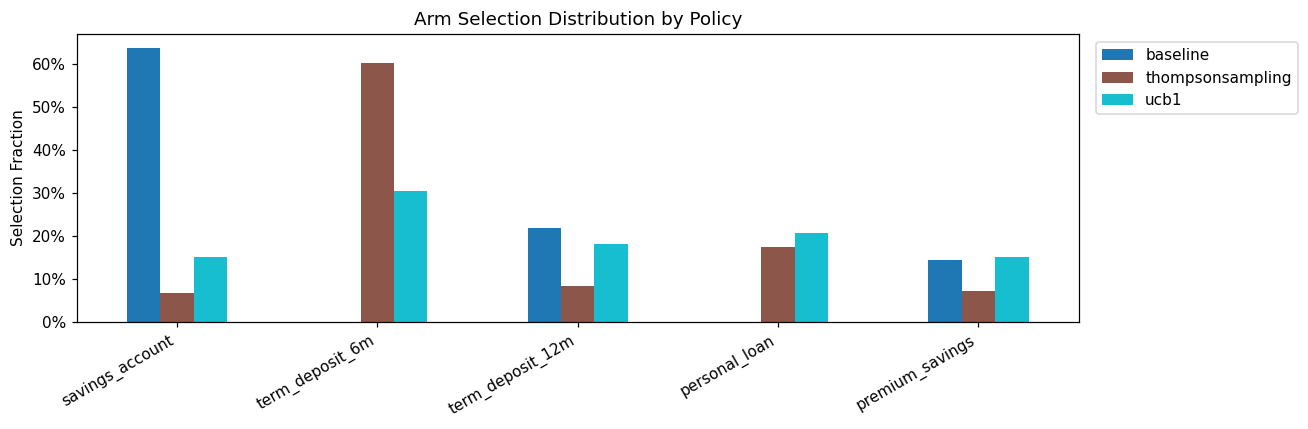

In [5]:
arm_dist_data = {}
for policy_name, result in results.items():
    if result.arm_distribution:
        arm_dist_data[policy_name] = result.arm_distribution

if arm_dist_data:
    dist_df = pd.DataFrame(arm_dist_data).fillna(0)
    dist_df.plot(kind="bar", figsize=(12, 4), colormap="tab10")
    plt.title("Arm Selection Distribution by Policy")
    plt.ylabel("Selection Fraction")
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.xticks(rotation=30, ha="right")
    plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No arm distribution data available.")

## 5. Statistical Summary

In [6]:
best_policy = summary["cumulative_reward"].idxmax()
worst_policy = summary["cumulative_reward"].idxmin()
best_avg = summary.loc[best_policy, "avg_reward"]
baseline_avg = summary.loc["baseline", "avg_reward"] if "baseline" in summary.index else None

print("=" * 50)
print("OFFLINE EVALUATION SUMMARY")
print("=" * 50)
print(f"Best policy:  {best_policy} ({best_avg:.3f} avg reward)")
print(f"Worst policy: {worst_policy}")
if baseline_avg:
    lift = (best_avg - baseline_avg) / baseline_avg * 100
    print(f"Lift over baseline: {lift:+.1f}%")
print()
print(summary.to_string())
print()
print("Methodology: Replay Method (Li et al., 2010)")
print("Only matched events (policy arm == historical arm) contribute to reward estimates.")
print("This provides an unbiased offline estimator of policy value.")

OFFLINE EVALUATION SUMMARY
Best policy:  thompsonsampling (0.072 avg reward)
Worst policy: baseline
Lift over baseline: +200.0%

                  cumulative_reward  avg_reward  regret  exploration_rate  total_cases
policy                                                                                
thompsonsampling               36.0       0.072    67.0             0.672          500
ucb1                           27.0       0.054    76.0             0.498          500
baseline                       12.0       0.024    91.0             0.000          500

Methodology: Replay Method (Li et al., 2010)
Only matched events (policy arm == historical arm) contribute to reward estimates.
This provides an unbiased offline estimator of policy value.


## 6. Export Results for MLflow

In [7]:
import dataclasses
import json
from pathlib import Path

output_dir = ROOT / "datasets" / "eval_results"
output_dir.mkdir(parents=True, exist_ok=True)

serializable = {}
for policy_name, result in results.items():
    d = dataclasses.asdict(result)
    serializable[policy_name] = {
        k: float(v) if isinstance(v, (float,)) else v
        for k, v in d.items()
        if not isinstance(v, list)
    }

out_path = output_dir / "offline_eval_summary.json"
with open(out_path, "w") as f:
    json.dump(serializable, f, indent=2)

print(f"Results saved to {out_path}")

Results saved to /Volumes/zeus/project/project_persona/git-portfolio/postech-fiap-ml-tech-challege-5-datathon/data/eval_results/offline_eval_summary.json
